In [1]:
%pip uninstall -y xgboost
%pip install --no-cache-dir --force-reinstall xgboost==1.7.6 pandas numpy matplotlib seaborn scikit-learn tensorflow shap ipywidgets

Found existing installation: xgboost 1.7.6
Uninstalling xgboost-1.7.6:
  Successfully uninstalled xgboost-1.7.6
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 14.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 17.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 18.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 6.3 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 15.2 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 16.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 8.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.8/562.8 kB 19.1 MB/s  0:00

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# xgboost may fail on macOS when OpenMP (libomp) is unavailable.
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("xgboost unavailable:", e)
    print("Proceeding without XGBoost. Install OpenMP (libomp) to enable it.")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import shap

In [3]:
df = pd.read_csv("crop_production.csv")

# Remove rows with missing Production values
df = df.dropna(subset=['Production'])

# Remove zero area to avoid division error
df = df[df['Area'] > 0]

# Create target variable: Yield = Production / Area
df['Yield'] = df['Production'] / df['Area']

# Remove any infinite or NaN values created from yield calculation
df = df[~df['Yield'].isin([np.inf, -np.inf])]
df = df.dropna(subset=['Yield'])

print("Data Shape after cleaning:", df.shape)
print("Crop_Year range:", df['Crop_Year'].min(), "-", df['Crop_Year'].max())
print("Unique crops:", df['Crop'].nunique())

Data Shape after cleaning: (242361, 8)
Crop_Year range: 1997 - 2015
Unique crops: 124


In [4]:
# Select features: keep Crop_Year for splitting, encode categoricals
df_encoded = df.copy()

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_encoded, columns=[
    'State_Name', 'District_Name', 'Season', 'Crop'
], drop_first=False)

# Drop the Production column (original, not our target)
df_encoded = df_encoded.drop(['Production'], axis=1)

print("Encoded data shape:", df_encoded.shape)
print("Columns:", df_encoded.shape[1])

Encoded data shape: (242361, 812)
Columns: 812


In [5]:
# Split data by year: train on data before 2010, test on 2010 and after
split_year = 2010

train = df_encoded[df_encoded['Crop_Year'] < split_year]
test = df_encoded[df_encoded['Crop_Year'] >= split_year]

print(f"Train set: {len(train)} rows (Crop_Year < {split_year})")
print(f"Test set: {len(test)} rows (Crop_Year >= {split_year})")

# Drop Crop_Year from features (it's not a model feature)
X_train = train.drop(['Crop_Year', 'Yield'], axis=1)
y_train = train['Yield']

X_test = test.drop(['Crop_Year', 'Yield'], axis=1)
y_test = test['Yield']

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Train set: 176742 rows (Crop_Year < 2010)
Test set: 65619 rows (Crop_Year >= 2010)

X_train shape: (176742, 810)
y_train shape: (176742,)
X_test shape: (65619, 810)
y_test shape: (65619,)


In [6]:
# Initialize models dictionary
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Add XGBoost only if available
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
else:
    print("⚠️  XGBoost unavailable - skipping XGBoost model")

results = {}
predictions = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    predictions[name] = pred

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

    print(f"\n{name} Completed:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")

# Display results summary
print("\n" + "="*50)
print("MODEL RESULTS SUMMARY")
print("="*50)
results_df = pd.DataFrame(results).T
print(results_df)

Training Random Forest...

Random Forest Completed:
  RMSE: 1207.8851
  MAE:  45.1523
  R²:   0.1182
Training XGBoost...

XGBoost Completed:
  RMSE: 1204.5201
  MAE:  46.4602
  R²:   0.1231

MODEL RESULTS SUMMARY
                      RMSE        MAE        R2
Random Forest  1207.885138  45.152326  0.118192
XGBoost        1204.520073  46.460180  0.123099


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

mlp.compile(optimizer='adam', loss='mse')

mlp.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=1)

mlp_pred = mlp.predict(X_test_scaled).flatten()

predictions["MLP"] = mlp_pred

rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mae = mean_absolute_error(y_test, mlp_pred)
r2 = r2_score(y_test, mlp_pred)

results["MLP"] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}

print("\nMLP Completed:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R2:   {r2:.4f}")

print("\n" + "="*50)
print("UPDATED MODEL RESULTS SUMMARY")
print("="*50)
results_df = pd.DataFrame(results).T
print(results_df)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 187461.2656
Epoch 2/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 139619.4062
Epoch 3/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 115811.6094
Epoch 4/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 102285.9688
Epoch 5/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 90637.2188
Epoch 6/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 83071.3594
Epoch 7/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 79909.4141
Epoch 8/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 75293.6797
Epoch 9/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 72871.5938
Epoch 10/10
5524/5524 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 70785.1484
2051/2051 ━━━━━━━━━━━━━━━━━━━━ 2s 838us/step

MLP Completed:
  RMSE: 1219.7140
  MAE:  82.1844
  R2:   0.1008

UPDATED MODEL RESULTS SUMMARY
                      RMSE        MAE        R2
Random Forest  1207.885138  45.152326  0.118192
XGBoost        120

In [8]:
results_df = pd.DataFrame(results, index=["RMSE", "MAE", "R2"]).T
print("\nFinal Comparison:\n", results_df)


Final Comparison:
                       RMSE        MAE        R2
Random Forest  1207.885138  45.152326  0.118192
XGBoost        1204.520073  46.460180  0.123099
MLP            1219.714037  82.184381  0.100836


In [9]:
def categorize(y):
    if y < 1000:
        return 0   # Low
    elif y < 3000:
        return 1   # Medium
    else:
        return 2   # High

y_test_cls = y_test.apply(categorize)

cls_results = {}

for name, pred in predictions.items():
    pred_cls = pd.Series(pred).apply(categorize)

    acc = accuracy_score(y_test_cls, pred_cls)
    cm = confusion_matrix(y_test_cls, pred_cls)

    cls_results[name] = acc

    print(f"\n{name} Classification:")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)


Random Forest Classification:
Accuracy: 0.9974702448985812
Confusion Matrix:
 [[65279     5    84]
 [    2     2     0]
 [   75     0   172]]

XGBoost Classification:
Accuracy: 0.9974397659214557
Confusion Matrix:
 [[65279     3    86]
 [    2     0     2]
 [   75     0   172]]

MLP Classification:
Accuracy: 0.990383882716896
Confusion Matrix:
 [[64817   439   112]
 [    2     0     2]
 [   75     1   171]]


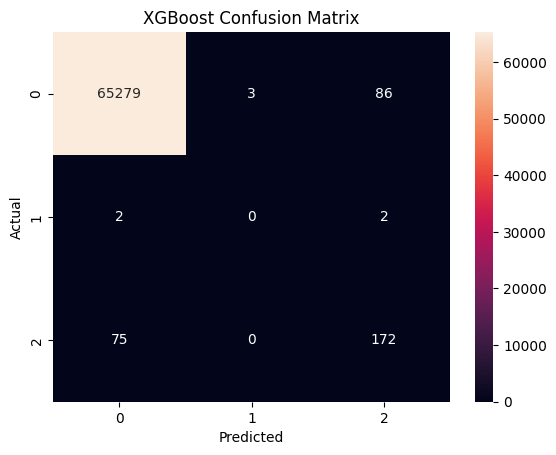

In [10]:
cm = confusion_matrix(y_test_cls, pd.Series(predictions["XGBoost"]).apply(categorize))

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

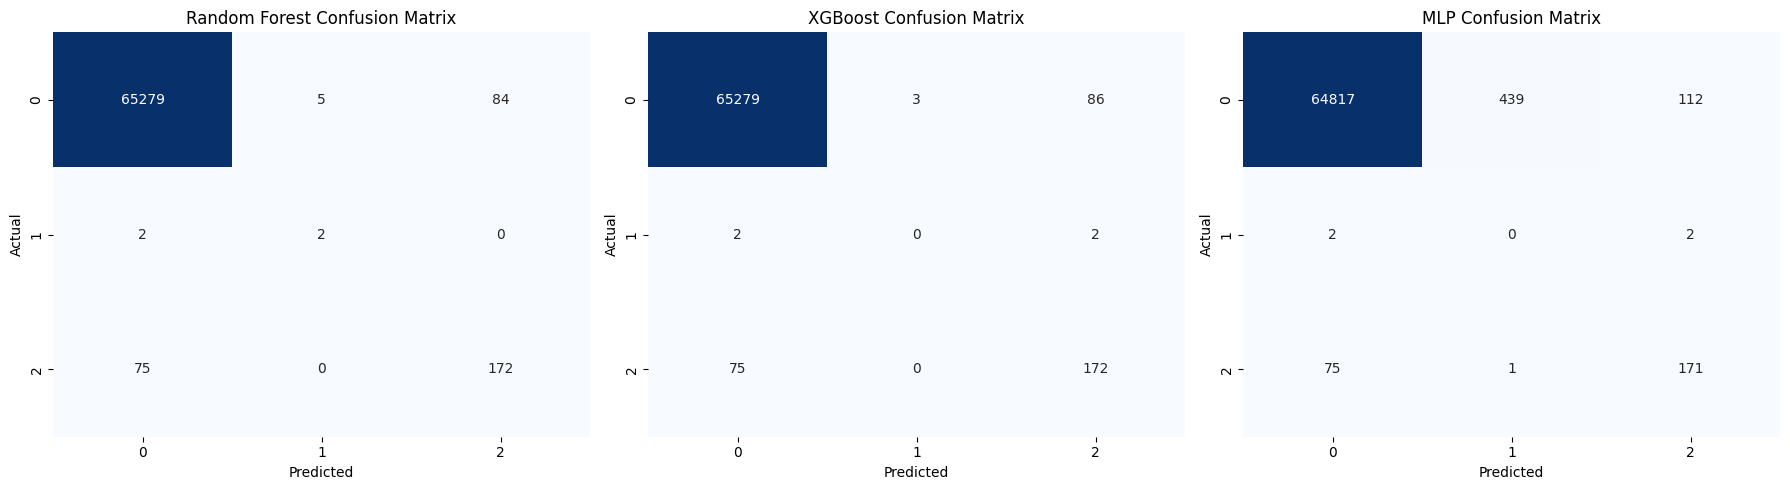

In [11]:
model_names = list(predictions.keys())
n_models = len(model_names)

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, name in zip(axes, model_names):
    cm_model = confusion_matrix(y_test_cls, pd.Series(predictions[name]).apply(categorize))
    sns.heatmap(cm_model, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

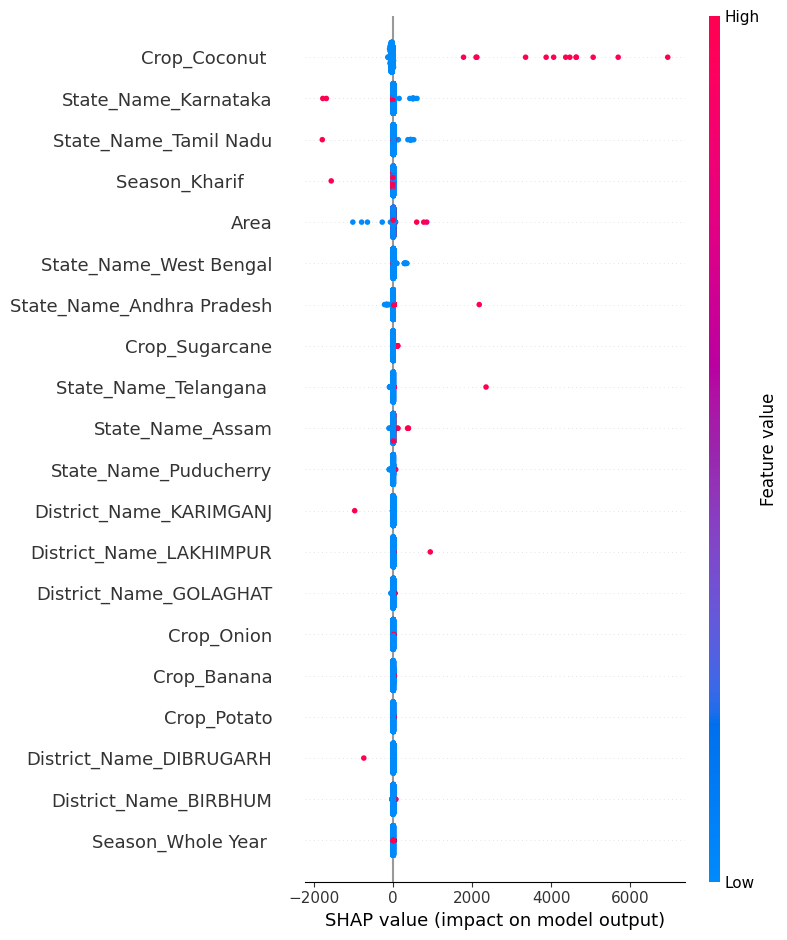

In [12]:
# SHAP explanation for XGBoost (sampled for faster runtime on large test data)
if "XGBoost" not in models:
    raise ValueError("XGBoost model not available in models dictionary.")

xgb_model = models["XGBoost"]
X_test_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_shap)

shap.summary_plot(shap_values, X_test_shap)

In [13]:
# Top-20 SHAP feature importance table for report
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False).head(20).reset_index(drop=True)

print("Top 20 Features by Mean |SHAP|:")
print(shap_importance_df)

Top 20 Features by Mean |SHAP|:
                      Feature  MeanAbsSHAP
0               Crop_Coconut     56.573292
1        State_Name_Karnataka     8.657104
2       State_Name_Tamil Nadu     6.237389
3          Season_Kharif          4.777014
4                        Area     4.546309
5      State_Name_West Bengal     3.813579
6   State_Name_Andhra Pradesh     3.669421
7              Crop_Sugarcane     3.601971
8       State_Name_Telangana      2.646741
9            State_Name_Assam     1.631891
10      State_Name_Puducherry     1.335437
11    District_Name_KARIMGANJ     0.611334
12    District_Name_LAKHIMPUR     0.601240
13     District_Name_GOLAGHAT     0.529598
14                 Crop_Onion     0.513247
15                Crop_Banana     0.511200
16                Crop_Potato     0.493333
17    District_Name_DIBRUGARH     0.462299
18      District_Name_BIRBHUM     0.357745
19         Season_Whole Year      0.331672


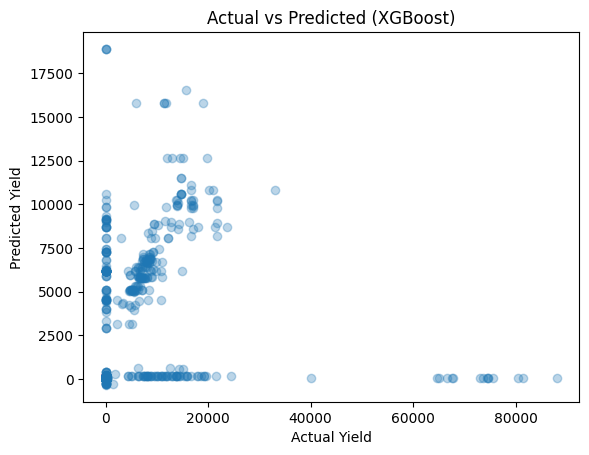

In [14]:
plt.figure()
plt.scatter(y_test, predictions["XGBoost"], alpha=0.3)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()

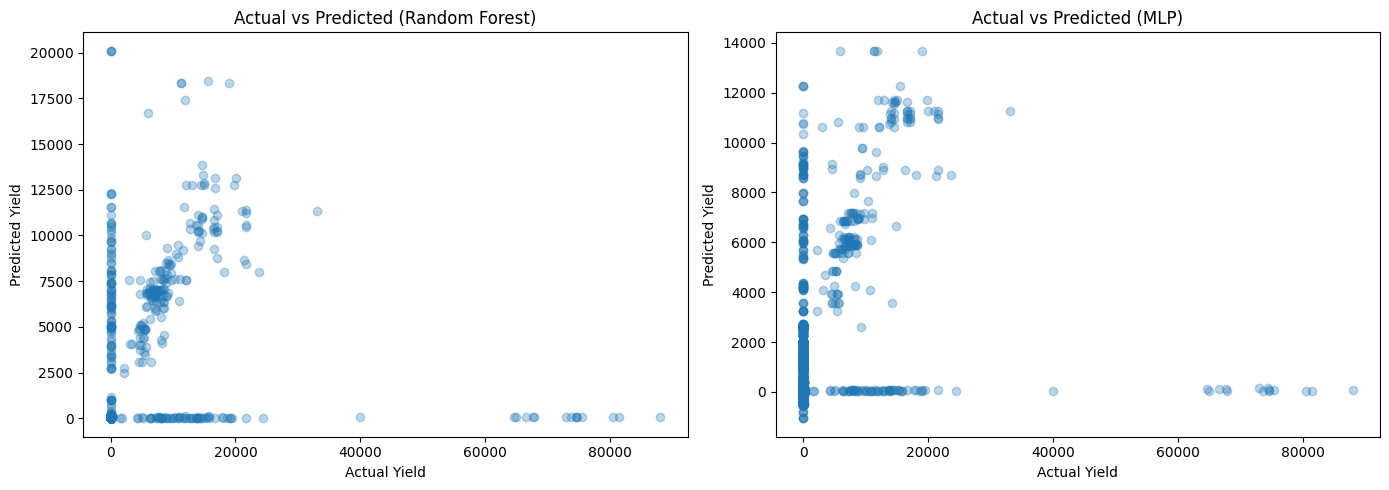

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, predictions["Random Forest"], alpha=0.3)
axes[0].set_xlabel("Actual Yield")
axes[0].set_ylabel("Predicted Yield")
axes[0].set_title("Actual vs Predicted (Random Forest)")

axes[1].scatter(y_test, predictions["MLP"], alpha=0.3)
axes[1].set_xlabel("Actual Yield")
axes[1].set_ylabel("Predicted Yield")
axes[1].set_title("Actual vs Predicted (MLP)")

plt.tight_layout()
plt.show()

In [16]:
# Build district-level error view using original dataframe rows for the test split
test_original = df.loc[test.index].copy()

test_original['Yield'] = y_test.values
test_original['Prediction'] = predictions["XGBoost"]
test_original['Error'] = abs(test_original['Yield'] - test_original['Prediction'])

error_by_district = test_original.groupby('District_Name')['Error'].mean()

print("\nTop Error Districts:\n", error_by_district.sort_values(ascending=False).head())


Top Error Districts:
 District_Name
FATEHGARH SAHIB    3286.383465
FAZILKA            2920.617087
PATHANKOT          2865.379793
KAPURTHALA         2730.472644
PATIALA            2319.185712
Name: Error, dtype: float64


In [18]:
# Multi-input prediction demo across all models
sample_inputs = [
    {"State_Name": "Karnataka", "District_Name": "BANGALORE", "Season": "Kharif", "Crop": "Rice", "Area": 1000.0},
    {"State_Name": "Punjab", "District_Name": "PATIALA", "Season": "Rabi", "Crop": "Wheat", "Area": 1500.0},
    {"State_Name": "West Bengal", "District_Name": "BIRBHUM", "Season": "Whole Year", "Crop": "Potato", "Area": 500.0}
]

def _match_dummy_column(prefix, value, columns):
    # Try exact match first
    exact = f"{prefix}_{value}"
    if exact in columns:
        return exact

    # Fallback: ignore extra spaces in category labels
    target = str(value).strip().lower()
    candidates = [c for c in columns if c.startswith(prefix + "_")]
    for c in candidates:
        if c.split("_", 1)[1].strip().lower() == target:
            return c
    return None

def predict_one_input(input_row):
    single_X = pd.DataFrame(0, index=[0], columns=X_train.columns)
    single_X.loc[0, "Area"] = float(input_row["Area"])

    mappings = {
        "State_Name": _match_dummy_column("State_Name", input_row["State_Name"], single_X.columns),
        "District_Name": _match_dummy_column("District_Name", input_row["District_Name"], single_X.columns),
        "Season": _match_dummy_column("Season", input_row["Season"], single_X.columns),
        "Crop": _match_dummy_column("Crop", input_row["Crop"], single_X.columns),
    }

    missing = []
    for key, col in mappings.items():
        if col is None:
            missing.append(f"{key}={input_row[key]}")
        else:
            single_X.loc[0, col] = 1

    rf_pred = float(models["Random Forest"].predict(single_X)[0])
    xgb_pred = float(models["XGBoost"].predict(single_X)[0]) if "XGBoost" in models else np.nan
    mlp_pred = float(mlp.predict(scaler.transform(single_X), verbose=0).flatten()[0])

    row_out = {
        "State_Name": input_row["State_Name"],
        "District_Name": input_row["District_Name"],
        "Season": input_row["Season"],
        "Crop": input_row["Crop"],
        "Area": input_row["Area"],
        "Pred_RF": rf_pred,
        "Pred_XGB": xgb_pred,
        "Pred_MLP": mlp_pred,
        "Class_RF": "Low" if rf_pred < 1000 else ("Medium" if rf_pred < 3000 else "High"),
        "Class_XGB": "Low" if xgb_pred < 1000 else ("Medium" if xgb_pred < 3000 else "High"),
        "Class_MLP": "Low" if mlp_pred < 1000 else ("Medium" if mlp_pred < 3000 else "High"),
        "Missing_Seen_Categories": ", ".join(missing) if missing else "None"
    }
    return row_out

demo_results = pd.DataFrame([predict_one_input(inp) for inp in sample_inputs])
print("Predictions for different inputs:")
display(demo_results)

Predictions for different inputs:


,State_Name,District_Name,Season,Crop,Area,Pred_RF,Pred_XGB,Pred_MLP,Class_RF,Class_XGB,Class_MLP,Missing_Seen_Categories
0,Karnataka,BANGALORE,Kharif,Rice,1000.0,1.713440,1.199793,-554.440918,Low,Low,Low,District_Name=BANGALORE
1,Punjab,PATIALA,Rabi,Wheat,1500.0,1.347748,1.241209,12.164186,Low,Low,Low,None
2,West Bengal,BIRBHUM,Whole Year,Potato,500.0,18.491654,20.789892,1.076448,Low,Low,Low,None


In [21]:
def build_sample_features(sample_row):
    # Build one encoded row with the exact training feature columns
    sample_df = pd.DataFrame(0, index=[0], columns=X_train.columns)

    # Numeric fields used by the trained models
    if 'Area' in sample_df.columns:
        sample_df.loc[0, 'Area'] = float(sample_row.get('Area', 0))

    # Optional: if user provides Crop_Year/Year, map if present in features
    year_val = sample_row.get('Crop_Year', sample_row.get('Year', None))
    if year_val is not None and 'Crop_Year' in sample_df.columns:
        sample_df.loc[0, 'Crop_Year'] = float(year_val)

    # Raw values expected: State_Name, District_Name, Season, Crop
    raw_cats = {
        'State_Name': sample_row.get('State_Name'),
        'District_Name': sample_row.get('District_Name'),
        'Season': sample_row.get('Season'),
        'Crop': sample_row.get('Crop')
    }

    # If one-hot keys are passed directly, set matching columns
    for k, v in sample_row.items():
        if isinstance(v, (int, float)) and v == 1 and k in sample_df.columns:
            sample_df.loc[0, k] = 1

    # Map raw categorical values with space-insensitive fallback
    for prefix, val in raw_cats.items():
        if val is None:
            continue
        exact_col = f"{prefix}_{val}"
        if exact_col in sample_df.columns:
            sample_df.loc[0, exact_col] = 1
        else:
            target = str(val).strip().lower()
            matches = [
                c for c in sample_df.columns
                if c.startswith(prefix + '_') and c.split('_', 1)[1].strip().lower() == target
            ]
            if matches:
                sample_df.loc[0, matches[0]] = 1

    return sample_df

def predict_sample(model, sample_row):
    sample_df = build_sample_features(sample_row)
    pred = model.predict(sample_df)[0]
    return float(pred)

sample = {
    'Crop_Year': 2015,
    'Area': 1000,
    'State_Name': 'Punjab',
    'District_Name': 'LUDHIANA',
    'Season': 'Kharif',
    'Crop': 'Rice'
}

# Tree models from models dict
for name, model in models.items():
    pred = predict_sample(model, sample)
    print(f"{name} Prediction: {pred}")

# MLP prediction (needs scaled input)
sample_df = build_sample_features(sample)
mlp_pred_single = float(mlp.predict(scaler.transform(sample_df), verbose=0).flatten()[0])
print(f"MLP Prediction: {mlp_pred_single}")

Random Forest Prediction: 3.456073007146285
XGBoost Prediction: 1.199792504310608
MLP Prediction: 15.919151306152344


In [22]:
# Predict with the best model based on lowest RMSE
best_model_name = min(results, key=lambda m: results[m]['RMSE'])
sample_df = build_sample_features(sample)

if best_model_name == 'MLP':
    best_pred = float(mlp.predict(scaler.transform(sample_df), verbose=0).flatten()[0])
else:
    best_pred = float(models[best_model_name].predict(sample_df)[0])

print(f"Best model by RMSE: {best_model_name}")
print(f"Best model prediction for sample: {best_pred}")
print(f"Predicted class: {'Low' if best_pred < 1000 else ('Medium' if best_pred < 3000 else 'High')}")

Best model by RMSE: XGBoost
Best model prediction for sample: 1.199792504310608
Predicted class: Low
